In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
from PIL import Image
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModelForDepthEstimation


In [2]:
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NOTEBOOK_ROOT = Path.cwd()
FOODSAM_OUTPUT_ROOT = (NOTEBOOK_ROOT / "../FoodSAM/nutrition50_foodSAM_outputs").resolve()
ZOE_OUTPUT_ROOT = (NOTEBOOK_ROOT / "../FoodSAM/zoedepth_nutrition50_outputs").resolve()
ZOE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"FoodSAM outputs: {FOODSAM_OUTPUT_ROOT}")
print(f"ZoeDepth outputs: {ZOE_OUTPUT_ROOT}")

TARGET_IMAGE_NAMES = ("enhance_vis.png", "pred_vis.png", "input.jpg")
SEED = 7
_ = torch.manual_seed(SEED)


FoodSAM outputs: /home/chahar/food_new/FoodSAM/nutrition50_foodSAM_outputs
ZoeDepth outputs: /home/chahar/food_new/FoodSAM/zoedepth_nutrition50_outputs


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained("Intel/zoedepth-nyu-kitti")
model = AutoModelForDepthEstimation.from_pretrained(
    "Intel/zoedepth-nyu-kitti",
    torch_dtype=torch.float32,
).to(device).eval()

print(f"Loaded ZoeDepth on {device}.")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded ZoeDepth on cuda.


In [ ]:
def pick_source_image(dish_dir: Path) -> Path | None:
    for name in TARGET_IMAGE_NAMES:
        candidate = dish_dir / name
        if candidate.exists():
            return candidate
    return None


def predict_depth_map(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        depth = outputs.predicted_depth  # (1, H, W)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=image.size[::-1],
            mode="bicubic",
            align_corners=False,
        )
        depth = depth.squeeze().cpu().numpy().astype(np.float32)

    return depth


def depth_to_colormap(depth: np.ndarray) -> Image.Image:
    finite_depth = depth[np.isfinite(depth)]
    if finite_depth.size == 0:
        raise ValueError("Depth map contains no finite values")

    lo = np.percentile(finite_depth, 2.0)
    hi = np.percentile(finite_depth, 98.0)
    if np.isclose(hi, lo):
        normalized = np.zeros_like(depth, dtype=np.float32)
    else:
        clipped = np.clip(depth, lo, hi)
        normalized = (clipped - lo) / (hi - lo)

    colormap = cm.magma(normalized)
    rgb = (colormap[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb)


In [5]:
records: List[Dict[str, object]] = []

for dish_dir in tqdm(sorted(FOODSAM_OUTPUT_ROOT.glob("dish_*")), desc="Dishes"):
    if not dish_dir.is_dir():
        continue

    source_image = pick_source_image(dish_dir)
    if source_image is None:
        print(f"No candidate image found for {dish_dir.name}, skipping.")
        continue

    depth = predict_depth_map(source_image)
    depth_vis = depth_to_colormap(depth)

    dish_output_dir = ZOE_OUTPUT_ROOT / dish_dir.name
    dish_output_dir.mkdir(parents=True, exist_ok=True)

    depth_basename = source_image.stem + "_zoedepth"
    depth_npy_path = dish_output_dir / f"{depth_basename}.npy"
    depth_png_path = dish_output_dir / f"{depth_basename}.png"

    np.save(depth_npy_path, depth)
    depth_vis.save(depth_png_path)

    records.append(
        {
            "dish_id": dish_dir.name,
            "source_image": source_image.relative_to(FOODSAM_OUTPUT_ROOT).as_posix(),
            "depth_npy": depth_npy_path.relative_to(ZOE_OUTPUT_ROOT).as_posix(),
            "depth_vis": depth_png_path.relative_to(ZOE_OUTPUT_ROOT).as_posix(),
            "depth_min": float(np.nanmin(depth)),
            "depth_max": float(np.nanmax(depth)),
        }
    )

print(f"Processed {len(records)} dishes.")


Dishes:   0%|          | 0/50 [00:00<?, ?it/s]

Processed 50 dishes.


In [6]:
summary_df = pd.DataFrame.from_records(records)
summary_path = ZOE_OUTPUT_ROOT / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Summary written to: {summary_path}")
summary_df.head()


Summary written to: /home/chahar/food_new/FoodSAM/zoedepth_nutrition50_outputs/summary.csv


,dish_id,source_image,depth_npy,depth_vis,depth_min,depth_max
0,dish_1556572657,dish_1556572657/enhance_vis.png,dish_1556572657/enhance_vis_zoedepth.npy,dish_1556572657/enhance_vis_zoedepth.png,0.883961,1.585565
1,dish_1556573514,dish_1556573514/enhance_vis.png,dish_1556573514/enhance_vis_zoedepth.npy,dish_1556573514/enhance_vis_zoedepth.png,0.848119,1.553573
2,dish_1556575014,dish_1556575014/enhance_vis.png,dish_1556575014/enhance_vis_zoedepth.npy,dish_1556575014/enhance_vis_zoedepth.png,0.838575,1.537683
3,dish_1556575083,dish_1556575083/enhance_vis.png,dish_1556575083/enhance_vis_zoedepth.npy,dish_1556575083/enhance_vis_zoedepth.png,0.851161,1.485513
4,dish_1556575124,dish_1556575124/enhance_vis.png,dish_1556575124/enhance_vis_zoedepth.npy,dish_1556575124/enhance_vis_zoedepth.png,0.868640,1.994904


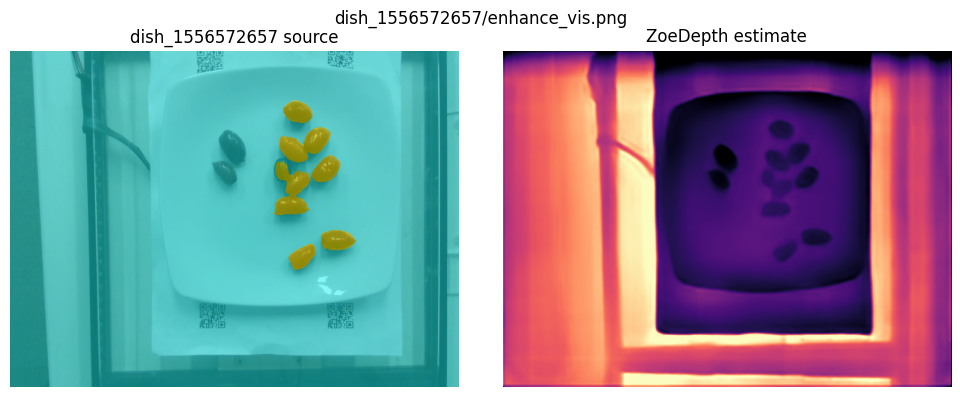

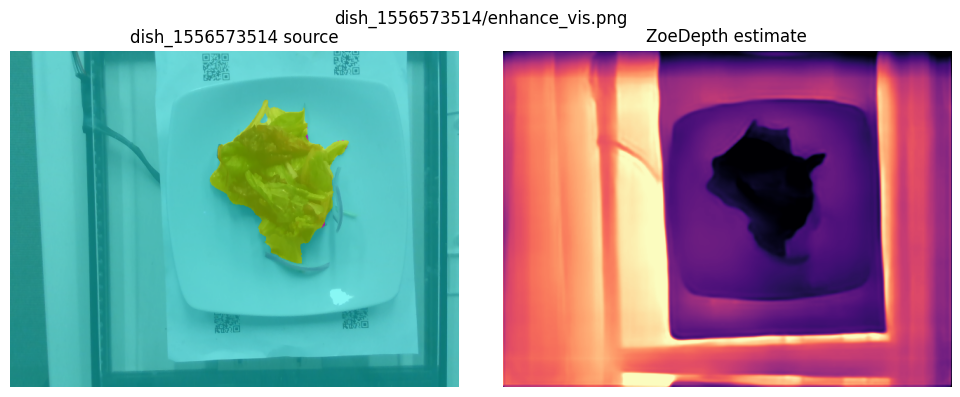

In [7]:
NUM_SAMPLES = 2
sample_df = summary_df.head(NUM_SAMPLES)

for _, row in sample_df.iterrows():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    src_path = FOODSAM_OUTPUT_ROOT / row["source_image"]
    depth_vis_path = ZOE_OUTPUT_ROOT / row["depth_vis"]

    axes[0].imshow(Image.open(src_path))
    axes[0].set_title(f"{row['dish_id']} source")
    axes[0].axis("off")

    axes[1].imshow(Image.open(depth_vis_path))
    axes[1].set_title("ZoeDepth estimate")
    axes[1].axis("off")

    fig.suptitle(row["source_image"])
    plt.tight_layout()
    plt.show()
